In [2]:
# ══════════════════════════════════════════════════════════════════
#  CELL 1 — Setup  (run once per session, ~3 min)
# ══════════════════════════════════════════════════════════════════
import os

GITHUB_TOKEN = "YOUR_GITHUB_TOKEN_HERE"   # ← paste your token

# ── 1. GPU check ──────────────────────────────────────────────────
import subprocess
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout[:500])

# ── 2. Clone repo ─────────────────────────────────────────────────
if not os.path.exists("autoresearch-lite"):
    result = subprocess.run(
        ["git", "clone",
         f"https://{GITHUB_TOKEN}@github.com/parthwhy/autoresearch-lite.git"],
        capture_output=True, text=True
    )
    print(result.stdout, result.stderr)

os.chdir("autoresearch-lite")
print("CWD:", os.getcwd())

# ── 3. Install uv + sync ──────────────────────────────────────────
subprocess.run(["pip", "install", "uv", "--quiet"], check=True)
subprocess.run(["uv", "sync"], check=True)

# ── 4. Install datasets ───────────────────────────────────────────
subprocess.run(["pip", "install", "datasets", "--quiet"], check=True)

# ── 5. Download TinyStories → parquet shards ──────────────────────
from datasets import load_dataset

DATA_DIR = os.path.expanduser("~/.cache/autoresearch/data")
os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_SHARD = os.path.join(DATA_DIR, "shard_00000.parquet")
VAL_SHARD   = os.path.join(DATA_DIR, "shard_06542.parquet")

if not os.path.exists(TRAIN_SHARD):
    print("Downloading TinyStories …")
    ds = load_dataset("roneneldan/TinyStories", split="train")
    n  = len(ds)
    ds.select(range(0, int(n * 0.95))).to_parquet(TRAIN_SHARD)
    ds.select(range(int(n * 0.95), n)).to_parquet(VAL_SHARD)
    print("Done — shards written.")
else:
    print("Shards already exist — skipping download.")

# ── 6. Prepare (tokenizer) ────────────────────────────────────────
result = subprocess.run(["uv", "run", "prepare.py", "--num-shards", "0"],
                        capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])

# ── 7. Git identity (needed for commits) ─────────────────────────
subprocess.run(["git", "config", "user.email", "autoresearch@kaggle"], capture_output=True)
subprocess.run(["git", "config", "user.name",  "AutoResearch Bot"],    capture_output=True)

# ── 8. Set remote with token ──────────────────────────────────────
subprocess.run(
    ["git", "remote", "set-url", "origin",
     f"https://{GITHUB_TOKEN}@github.com/parthwhy/autoresearch-lite.git"],
    capture_output=True
)

print("\n✅ Setup complete — ready to train.")


Thu Mar 12 11:43:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       
 Cloning into 'autoresearch-lite'...

CWD: /kaggle/working/autoresearch-lite
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 71.8 MB/s eta 0:00:00


Using CPython 3.10.12 interpreter at: /usr/bin/python3.10
Creating virtual environment at: .venv
Resolved 74 packages in 0.89ms
Prepared 67 packages in 1m 02s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 67 packages in 12.52s
 + annotated-doc==0.0.4
 + anyio==4.12.1
 + certifi==2026.2.25
 + charset-normalizer==3.4.4
 + click==8.3.1
 + contourpy==1.3.2
 + cycler==0.12.1
 + exceptiongroup==1.3.1
 + filelock==3.24.3
 + fonttools==4.61.1
 + fsspec==2026.2.0
 + h11==0.16.0
 + hf-xet==1.3.1
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.5.0
 + idna==3.11
 + jinja2==3.1.6
 + kernels==0.12.1
 + kiwisolver==1.4.9
 + markdown-it-py==4.0.0
 + markupsafe==3.0.3
 + matplotlib==3.10.8
 + mdurl==0.1.2
 + mpmath==1.3.0
 + networkx==3.4.2
 + numpy==2.2.6
 + nvidia-cublas-cu12==12.8.4.1
 + nvidia-cuda-cupt

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2014 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/106 [00:00<?, ?ba/s]

Done — shards written.
Cache directory: /root/.cache/autoresearch

Data: all 1 shards already downloaded at /root/.cache/autoresearch/data

Tokenizer: training BPE tokenizer...
Tokenizer: trained in 74.1s, saved to /root/.cache/autoresearch/tokenizer/tokenizer.pkl
Tokenizer: building token_bytes lookup...
Tokenizer: saved token_bytes to /root/.cache/autoresearch/tokenizer/token_bytes.pt
Tokenizer: sanity check passed (vocab_size=2048)

Done! Ready to train.


✅ Setup complete — ready to train.


In [18]:
MODEL = "nvidia/nemotron-3-super-120b-a12b:free"        # 120B reasoning model, better at following instructions than smaller free models

OPENROUTER_KEYS = [
    "xxxx"
    # add more if you have them sepreted by commas
]
current_key_idx = 0

def get_llm_response(messages, retries=5):
    global current_key_idx, OPENROUTER_API_KEY
    for attempt in range(retries):
        try:
            resp = requests.post(
                "https://openrouter.ai/api/v1/chat/completions",
                headers={
                    "Authorization": f"Bearer {OPENROUTER_KEYS[current_key_idx]}",
                    "Content-Type": "application/json",
                },
                json={
                    "model": MODEL,
                    "messages": messages,
                    "max_tokens": 2000,
                    "temperature": 0.7,
                    "reasoning": {"enabled": True}
                },
                timeout=90,
            )
            data = resp.json()
            if "choices" in data:
                content = data["choices"][0]["message"].get("content")
                if content:
                    return content.strip()
                reasoning = data["choices"][0]["message"].get("reasoning", "")
                print(f"  ⚠️  content empty, reasoning: {reasoning[:100]}")
                return None
            err = data.get("error", {})
            code = err.get("code", resp.status_code)
            # rotate key on 429 or quota errors
            if code in [429, 402]:
                print(f"  🔄 Key {current_key_idx} exhausted — rotating")
                current_key_idx = (current_key_idx + 1) % len(OPENROUTER_KEYS)
                continue
            print(f"  ⚠️  API error (attempt {attempt+1}): {code} — {err.get('message','')[:80]}")
            wait = 2 ** (attempt + 2)
            print(f"  Waiting {wait}s …")
            time.sleep(wait)
        except Exception as e:
            print(f"  ⚠️  Request exception: {e}")
            time.sleep(10)
    return None

print("✅ multi-key ready")

✅ multi-key ready


In [4]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2 — Helper functions  (run once)
# ══════════════════════════════════════════════════════════════════
import os, subprocess, requests, time, json


# ── Training runner ───────────────────────────────────────────────
def run_training():
    result = subprocess.run(
        ["uv", "run", "train.py"],
        capture_output=True, text=True
    )
    combined = result.stdout + result.stderr
    with open("run.log", "w") as f:
        f.write(combined)
    val_bpb = peak_vram = None
    for line in combined.split("\n"):
        if line.startswith("val_bpb:"):
            val_bpb   = float(line.split()[1])
        if line.startswith("peak_vram_mb:"):
            peak_vram = float(line.split()[1])
    return val_bpb, peak_vram

def get_log_tail(n=20):
    try:
        return "".join(open("run.log").readlines()[-n:])
    except:
        return "no log"

# ── Git helpers ───────────────────────────────────────────────────
def git_commit(msg):
    subprocess.run(["git", "add", "train.py", "results.tsv"], capture_output=True)
    subprocess.run(["git", "commit", "-m", msg], capture_output=True)
    h = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                       capture_output=True, text=True)
    return h.stdout.strip()

def git_revert():
    subprocess.run(["git", "checkout", "train.py"], capture_output=True)

# ── Results logger ────────────────────────────────────────────────
def save_result(commit, val_bpb, peak_vram, status, description):
    if not os.path.exists("results.tsv"):
        with open("results.tsv", "w") as f:
            f.write("commit\tval_bpb\tmemory_gb\tstatus\tdescription\n")
    memory_gb = round(peak_vram / 1024, 2) if peak_vram else 0.0
    bpb_str   = f"{val_bpb:.6f}" if val_bpb else "FAILED"
    with open("results.tsv", "a") as f:
        f.write(f"{commit}\t{bpb_str}\t{memory_gb}\t{status}\t{description}\n")
    print(f"  📋 {commit[:7]} | {bpb_str} | {memory_gb}GB | {status} | {description}")

def get_results():
    try:
        return open("results.tsv").read()
    except:
        return "No results yet."

# ── Agent prompt builder ──────────────────────────────────────────
HPARAM_SECTION = """ASPECT_RATIO = 64
HEAD_DIM = 128
WINDOW_PATTERN = "L"
TOTAL_BATCH_SIZE = 2**14
EMBEDDING_LR = 0.6
UNEMBEDDING_LR = 0.004
MATRIX_LR = 0.04
SCALAR_LR = 0.5
WEIGHT_DECAY = 0.2
ADAM_BETAS = (0.8, 0.95)
WARMUP_RATIO = 0.0
WARMDOWN_RATIO = 0.5
FINAL_LR_FRAC = 0.0
DEPTH = 4
DEVICE_BATCH_SIZE = 32"""
def build_messages(history_str, best_bpb):
    return [
        {
            "role": "user",
            "content": f"""You are optimizing a GPT training script. Minimize val_bpb (lower=better). Best so far: {best_bpb:.6f}

HARDWARE: Tesla T4 (15GB VRAM). Only ~1.5GB used — headroom to increase model size.
Do NOT change: flash attention, evaluate_bpb, TIME_BUDGET, imports.
Make EXACTLY ONE change.

Experiment history (do not repeat these):
{history_str}

Current hyperparameters:
ASPECT_RATIO = 64
HEAD_DIM = 128
WINDOW_PATTERN = "L"
TOTAL_BATCH_SIZE = 2**14
EMBEDDING_LR = 0.6
UNEMBEDDING_LR = 0.004
MATRIX_LR = 0.04
SCALAR_LR = 0.5
WEIGHT_DECAY = 0.2
ADAM_BETAS = (0.8, 0.95)
WARMUP_RATIO = 0.0
WARMDOWN_RATIO = 0.5
FINAL_LR_FRAC = 0.0
DEPTH = 4
DEVICE_BATCH_SIZE = 32

RESPONSE FORMAT (exactly this):
DESCRIPTION: one sentence
OLD:
<exact line>
NEW:
<replacement line>"""
        }
    ]

# ── Change applicator ─────────────────────────────────────────────
def apply_change(response, current_train):
    lines = response.strip().split("\n")
    old_lines, new_lines = [], []
    section = None
    description = "agent change"

    for line in lines:
        stripped = line.strip()
        if stripped.startswith("DESCRIPTION:"):
            description = stripped[len("DESCRIPTION:"):].strip()
        elif stripped == "OLD:":
            section = "old"
        elif stripped == "NEW:":
            section = "new"
        elif section == "old":
            old_lines.append(line)
        elif section == "new":
            new_lines.append(line)

    old_str = "\n".join(old_lines).strip()
    new_str = "\n".join(new_lines).strip()

    if not old_str:
        return None, None, description + " [PARSE_FAIL: no OLD block]"
    if old_str not in current_train:
        return None, None, description + f" [PARSE_FAIL: OLD not found: {old_str!r:.60}]"

    new_train = current_train.replace(old_str, new_str, 1)
    return new_train, f"{old_str!r:.40} → {new_str!r:.40}", description

print("✅ Helpers loaded.")


✅ Helpers loaded.


In [19]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3 — Agent loop
#  Runs MAX_EXPERIMENTS iterations; safe to interrupt and re-run.
# ══════════════════════════════════════════════════════════════════
MAX_EXPERIMENTS = 20
BASELINE_BPB    = 0.686159   # established on Colab T4

# ── Restore known best from results.tsv (resume-safe) ────────────
best_bpb = BASELINE_BPB
history  = []

if os.path.exists("results.tsv"):
    for line in open("results.tsv").readlines()[1:]:
        parts = line.strip().split("\t")
        if len(parts) >= 4 and parts[3] == "keep":
            try:
                best_bpb = min(best_bpb, float(parts[1]))
            except:
                pass
        if len(parts) >= 5:
            history.append(f"{parts[3].upper()} | bpb={parts[1]} | {parts[4]}")

print(f"▶ Resuming — best so far: {best_bpb:.6f}")
print(f"▶ History entries loaded: {len(history)}")
print(f"▶ Model: {MODEL}")
print("=" * 60)

# ── Main loop ─────────────────────────────────────────────────────
for i in range(MAX_EXPERIMENTS):
    exp_num = i + 1
    print(f"\n[Experiment {exp_num}/{MAX_EXPERIMENTS}]")

    with open("train.py", "r") as f:
        current_train = f.read()

    # Build history string (last 6, most recent first)
    history_str = "\n".join(reversed(history[-6:])) if history else "No experiments yet."

    messages = build_messages(history_str, best_bpb)

    # ── Ask the agent ──────────────────────────────────────────────
    print("  🧠 Agent thinking …")
    response = get_llm_response(messages)

    if response is None:
        print("  ⚠️  No response from LLM — skipping")
        history.append(f"Exp {exp_num}: LLM_FAIL")
        continue

    # Strip thinking tags some models emit
    if "<think>" in response:
        response = response.split("</think>")[-1].strip()

    print(f"  Agent: {response[:200]}")

    # ── Parse OLD/NEW ──────────────────────────────────────────────
    new_train, change_str, description = apply_change(response, current_train)

    if new_train is None:
        print(f"  ⚠️  {description}")
        history.append(f"Exp {exp_num}: PARSE_FAIL — {description}")
        continue

    if new_train == current_train:
        print("  ⚠️  No actual change — skipping")
        history.append(f"Exp {exp_num}: NO_CHANGE")
        continue

    print(f"  📝 {description}")

    # ── Write & train ──────────────────────────────────────────────
    with open("train.py", "w") as f:
        f.write(new_train)

    print("  🏃 Training …")
    val_bpb, peak_vram = run_training()

    # ── Evaluate result ────────────────────────────────────────────
    if val_bpb is None:
        print("  💥 CRASHED")
        print(get_log_tail())
        git_revert()
        save_result("0000000", None, 0, "crash", description)
        history.append(f"Exp {exp_num}: CRASHED — {description}")
        continue

    kept = val_bpb < best_bpb

    if kept:
        best_bpb = val_bpb
        commit = git_commit(f"exp_{exp_num}: {description[:60]}")
        save_result(commit, val_bpb, peak_vram, "keep", description)
        print(f"  ✅ KEPT  {val_bpb:.6f}  (Δ from baseline: {BASELINE_BPB - best_bpb:+.6f})")
        history.append(f"Exp {exp_num}: KEPT bpb={val_bpb:.6f} — {description}")
    else:
        git_revert()
        save_result("discarded", val_bpb, peak_vram, "discard", description)
        print(f"  ❌ DISCARD  {val_bpb:.6f}  (best: {best_bpb:.6f})")
        history.append(f"Exp {exp_num}: DISCARD bpb={val_bpb:.6f} — {description}")

# ── Push results ───────────────────────────────────────────────────
subprocess.run(["git", "add", "results.tsv"], capture_output=True)
subprocess.run(["git", "commit", "-m", "update results.tsv"], capture_output=True)
subprocess.run(["git", "push", "origin", "HEAD"], capture_output=True)

print(f"\n{'=' * 60}")
print(f"✅ Done.  Baseline: {BASELINE_BPB:.6f}  |  Best: {best_bpb:.6f}  |  Δ: {BASELINE_BPB - best_bpb:+.6f}")
print("\nFinal results.tsv:")
print(get_results())


▶ Resuming — best so far: 0.686159
▶ History entries loaded: 1
▶ Model: nvidia/nemotron-3-super-120b-a12b:free

[Experiment 1/3]
  🧠 Agent thinking …
  Agent: DESCRIPTION: Reduce device batch size to increase gradient noise and potentially improve generalization.
OLD:
DEVICE_BATCH_SIZE = 32
NEW:
DEVICE_BATCH_SIZE = 16
  📝 Reduce device batch size to increase gradient noise and potentially improve generalization.
  🏃 Training …
  📋 discard | 0.693976 | 0.48GB | discard | Reduce device batch size to increase gradient noise and potentially improve generalization.
  ❌ DISCARD  0.693976  (best: 0.686159)

[Experiment 2/3]
  🧠 Agent thinking …
  Agent: DESCRIPTION: Reduce DEVICE_BATCH_SIZE to increase gradient noise and potentially improve generalization.
OLD:
DEVICE_BATCH_SIZE = 32
NEW:
DEVICE_BATCH_SIZE = 16
  📝 Reduce DEVICE_BATCH_SIZE to increase gradient noise and potentially improve generalization.
  🏃 Training …
  📋 discard | 0.694179 | 0.48GB | discard | Reduce DEVICE_BATCH_SIZE to i

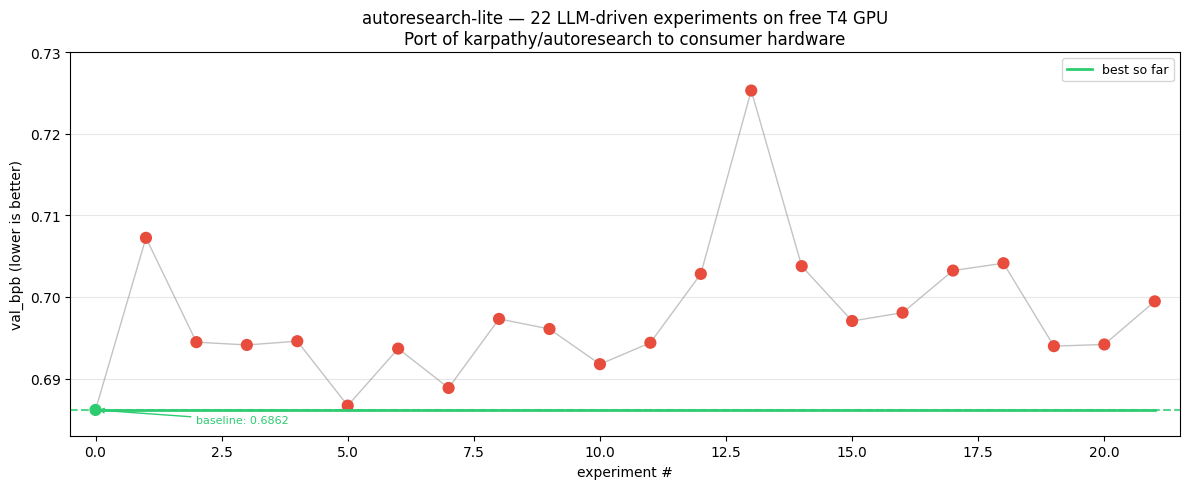

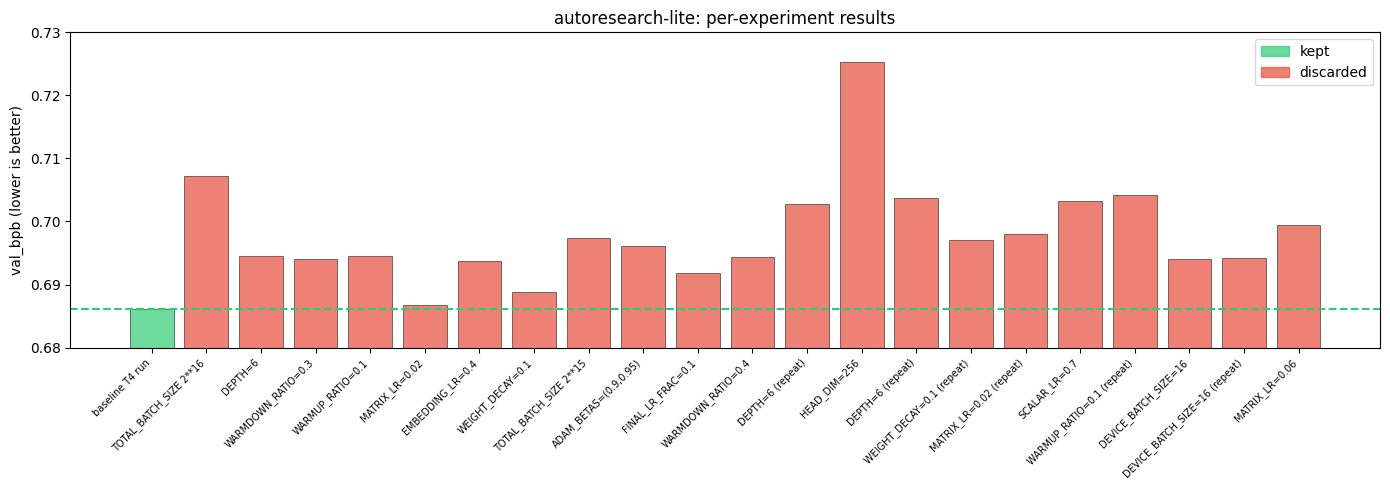

In [43]:
# ── Plot 1: Line plot (Karpathy style) ────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
df_plot = df[df["status"] != "crash"].copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2ecc71" if s == "keep" else "#e74c3c" for s in df_plot["status"]]
ax.scatter(range(len(df_plot)), df_plot["val_bpb"], c=colors, s=60, zorder=5)
ax.plot(range(len(df_plot)), df_plot["val_bpb"], color="#888888", linewidth=1, alpha=0.5, zorder=4)
ax.axhline(y=0.686159, color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.8)

running_min = df_plot["val_bpb"].cummin()
ax.plot(range(len(df_plot)), running_min, color="#2ecc71", linewidth=2, zorder=6, label="best so far")

ax.annotate("baseline: 0.6862", xy=(0, 0.686159), xytext=(2, 0.6845),
            fontsize=8, color="#2ecc71",
            arrowprops=dict(arrowstyle="->", color="#2ecc71", lw=1))

ax.set_xlabel("experiment #")
ax.set_ylabel("val_bpb (lower is better)")
ax.set_title("autoresearch-lite — 22 LLM-driven experiments on free T4 GPU\nPort of karpathy/autoresearch to consumer hardware")
ax.set_xlim(-0.5, len(df_plot) - 0.5)
ax.set_ylim(0.683, 0.730)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Bar plot ───────────────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))

colors2 = ["#2ecc71" if s == "keep" else "#e74c3c" for s in df_plot["status"]]
ax.bar(range(len(df_plot)), df_plot["val_bpb"], color=colors2, alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axhline(y=0.686159, color="#2ecc71", linestyle="--", linewidth=1.5)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot["description"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("val_bpb (lower is better)")
ax.set_title("autoresearch-lite: per-experiment results")
ax.set_ylim(0.68, 0.73)

keep_patch    = mpatches.Patch(color="#2ecc71", alpha=0.7, label="kept")
discard_patch = mpatches.Patch(color="#e74c3c", alpha=0.7, label="discarded")
ax.legend(handles=[keep_patch, discard_patch])
plt.tight_layout()
plt.show()